# 03 - CIFAR-10: 2D CNN

CIFAR-10 là bài toán phân loại ảnh 10 lớp. Notebook này dùng CNN 2D tự xây dựng, không dùng ResNet/transfer learning, để tập trung vào bản chất CNN.


## Kiến thức CNN được áp dụng

Notebook này minh họa trực tiếp các khái niệm:

- **Tensor / Channel / Feature map**
- **Convolution**: kernel/filter quét trên vùng cục bộ
- **Local connectivity**
- **Parameter sharing**
- **ReLU**: đưa phi tuyến vào mạng
- **Pooling / Downsampling**
- **Receptive field** tăng dần qua các block
- **Hierarchical feature extraction**
- **Function composition**:

\[
F = f_{classifier}\circ f_{block3}\circ f_{block2}\circ f_{block1}
\]

Mỗi block có dạng:

\[
f_{block}=f_{pool}\circ f_{ReLU}\circ f_{Conv}
\]

- **Loss → Backpropagation → Gradient → Optimizer** để học kernel/weights.


In [1]:

# ============================================================
# CNN FROM SCRATCH IN PYTORCH - COMMON SETUP
# ============================================================
import os, random, time, json, copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
torch.backends.cudnn.benchmark = True

DEVICE: cuda


In [2]:
# =========================
# 1. LOAD CIFAR-10 (dữ liệu local, dạng thư mục ảnh)
# =========================
DATA_ROOT = "../data/cifar10"
IMG_SIZE = 32
BATCH_SIZE = 128

train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465), (0.2470,0.2435,0.2616))
])
eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465), (0.2470,0.2435,0.2616))
])

train_full = datasets.ImageFolder(os.path.join(DATA_ROOT, "train"), transform=train_tf)
test_ds = datasets.ImageFolder(os.path.join(DATA_ROOT, "test"), transform=eval_tf)

n_train = int(0.90 * len(train_full))
n_val = len(train_full) - n_train
g = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(train_full, [n_train, n_val], generator=g)

# Dùng eval transform cho validation (không augment)
val_ds.dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, "train"), transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=4, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=4, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True, persistent_workers=True)

classes = train_full.classes
print(classes)
print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train: 45000 Val: 5000 Test: 10000


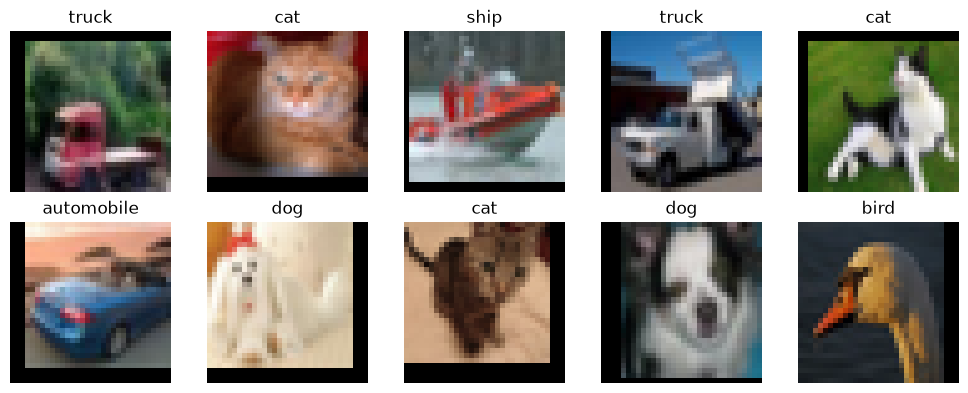

In [3]:

# =========================
# 2. SAMPLE IMAGES
# =========================
images, labels = next(iter(train_loader))
mean = torch.tensor([0.4914,0.4822,0.4465]).view(3,1,1)
std = torch.tensor([0.2470,0.2435,0.2616]).view(3,1,1)

fig, axes = plt.subplots(2,5, figsize=(10,4))
for ax, img, lab in zip(axes.ravel(), images[:10], labels[:10]):
    img = (img.cpu()*std + mean).clamp(0,1)
    ax.imshow(img.permute(1,2,0))
    ax.set_title(classes[lab])
    ax.axis("off")
plt.tight_layout()
plt.show()


In [4]:

# =========================
# 3. CNN 2D
# =========================
class CIFAR10_CNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # 32x32 -> 32x32
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # 32x32 -> 16x16
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 16x16 -> 8x8
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 8x8 -> 4x4
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1,1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.35),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = CIFAR10_CNN().to(DEVICE)
print(model)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


CIFAR10_CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU()
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(k

In [7]:
from tqdm import tqdm 
from torch.cuda.amp import autocast, GradScaler

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=5e-4)
scaler = GradScaler()

def eval_loader(loader):
    model.eval()
    total_loss, correct, total = 0,0,0
    with torch.no_grad():
        for xb,yb in loader:
            xb,yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            with autocast():
                logits = model(xb)
                loss = criterion(logits,yb)
            total_loss += loss.item()*len(yb)
            correct += (logits.argmax(1)==yb).sum().item()
            total += len(yb)
    return total_loss/total, correct/total

EPOCHS = 25
history = {"train_loss":[],"val_loss":[],"train_acc":[],"val_acc":[]}
best_state, best_val = None, float("inf")

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0,0,0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for xb,yb in pbar:
        xb,yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        with autocast():
            logits = model(xb)
            loss = criterion(logits,yb)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()*len(yb)
        correct += (logits.argmax(1)==yb).sum().item()
        total += len(yb)
        pbar.set_postfix(loss=running_loss/total, acc=correct/total)

    tr_loss, tr_acc = running_loss/total, correct/total
    va_loss, va_acc = eval_loader(val_loader)
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)

    if va_loss < best_val:
        best_val = va_loss
        best_state = copy.deepcopy(model.state_dict())

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
          f"val loss={va_loss:.4f}, acc={va_acc:.4f}")

model.load_state_dict(best_state)

C:\Users\admin\AppData\Local\Temp\ipykernel_6460\2371084790.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1/25:   0%|          | 0/352 [00:00<?, ?it/s]C:\Users\admin\AppData\Local\Temp\ipykernel_6460\2371084790.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/25: 100%|██████████| 352/352 [00:30<00:00, 11.58it/s, acc=0.409, loss=1.6] 
C:\Users\admin\AppData\Local\Temp\ipykernel_6460\2371084790.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 01/25 | train loss=1.5996, acc=0.4088 | val loss=1.2787, acc=0.5298


Epoch 2/25: 100%|██████████| 352/352 [00:09<00:00, 36.36it/s, acc=0.55, loss=1.25] 


Epoch 02/25 | train loss=1.2469, acc=0.5499 | val loss=1.1955, acc=0.5686


Epoch 3/25: 100%|██████████| 352/352 [00:10<00:00, 35.17it/s, acc=0.603, loss=1.12]


...

Epoch 24/25: 100%|██████████| 352/352 [00:09<00:00, 35.76it/s, acc=0.821, loss=0.522]


Epoch 24/25 | train loss=0.5219, acc=0.8209 | val loss=0.5943, acc=0.8026


Epoch 25/25: 100%|██████████| 352/352 [00:10<00:00, 34.27it/s, acc=0.823, loss=0.516]


Epoch 25/25 | train loss=0.5156, acc=0.8229 | val loss=0.7865, acc=0.7480


<All keys matched successfully>

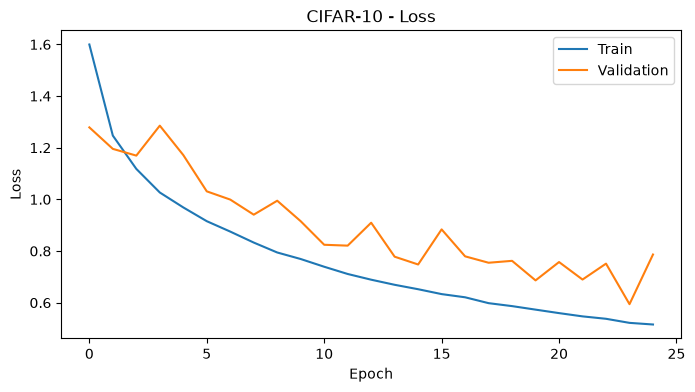

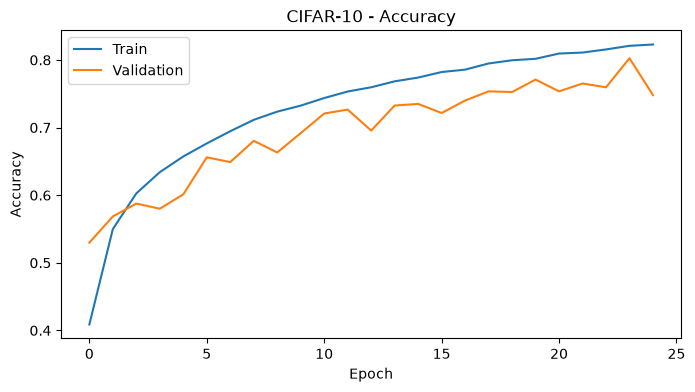

In [8]:

# =========================
# 5. CURVES
# =========================
plt.figure(figsize=(8,4))
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("CIFAR-10 - Loss"); plt.legend(); plt.show()

plt.figure(figsize=(8,4))
plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Validation")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("CIFAR-10 - Accuracy"); plt.legend(); plt.show()


              precision    recall  f1-score   support

    airplane     0.7936    0.8460    0.8190      1000
  automobile     0.7692    0.9630    0.8552      1000
        bird     0.7032    0.7440    0.7230      1000
         cat     0.6522    0.6770    0.6644      1000
        deer     0.7523    0.8200    0.7847      1000
         dog     0.8042    0.6490    0.7183      1000
        frog     0.8656    0.8440    0.8547      1000
       horse     0.8732    0.8330    0.8526      1000
        ship     0.9342    0.8380    0.8835      1000
       truck     0.9166    0.7910    0.8492      1000

    accuracy                         0.8005     10000
   macro avg     0.8064    0.8005    0.8005     10000
weighted avg     0.8064    0.8005    0.8005     10000



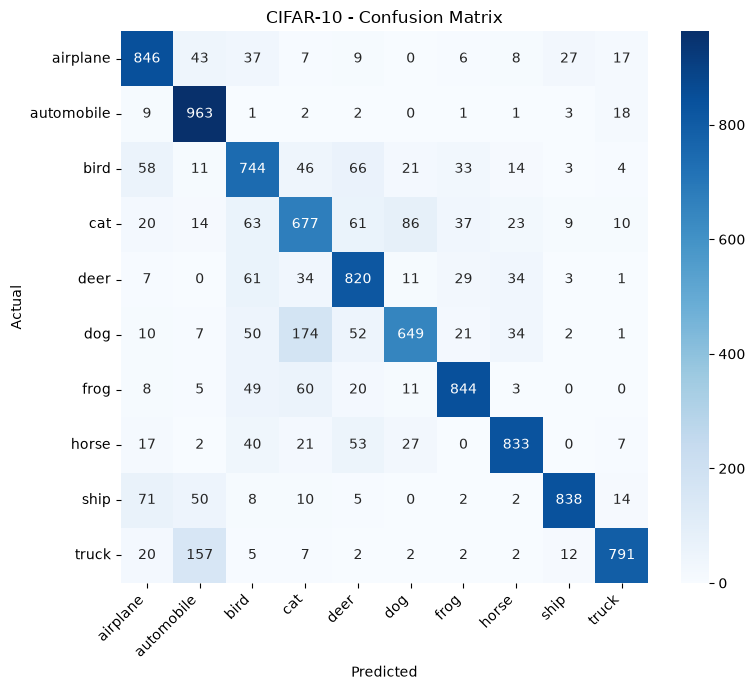

In [9]:

# =========================
# 6. TEST
# =========================
model.eval()
preds, truths = [], []
with torch.no_grad():
    for xb,yb in test_loader:
        logits = model(xb.to(DEVICE))
        preds.extend(logits.argmax(1).cpu().numpy())
        truths.extend(yb.numpy())

print(classification_report(truths, preds, target_names=classes, digits=4))

cm = confusion_matrix(truths, preds)
plt.figure(figsize=(8,7))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("CIFAR-10 - Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


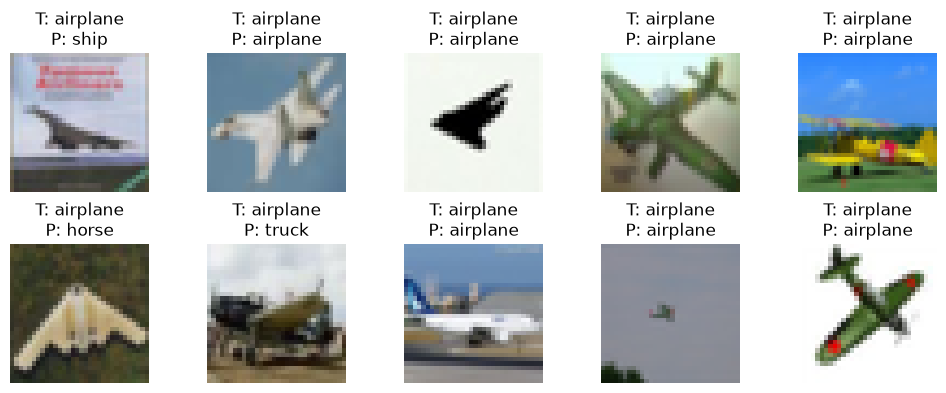

In [10]:

# =========================
# 7. VISUALIZE PREDICTIONS
# =========================
xb, yb = next(iter(test_loader))
with torch.no_grad():
    pred = model(xb.to(DEVICE)).argmax(1).cpu()

fig, axes = plt.subplots(2,5, figsize=(10,4))
for ax, img, true, p in zip(axes.ravel(), xb[:10], yb[:10], pred[:10]):
    img = (img.cpu()*std + mean).clamp(0,1)
    ax.imshow(img.permute(1,2,0))
    ax.set_title(f"T: {classes[true]}\nP: {classes[p]}")
    ax.axis("off")
plt.tight_layout()
plt.show()


### Liên hệ với lý thuyết

CIFAR-10 cho thấy rõ pipeline CNN 2D: ảnh RGB là tensor \(3\times32\times32\); mỗi `Conv2d` học các kernel dùng chung trên nhiều vị trí; `ReLU` tạo phi tuyến; `MaxPool2d` giảm kích thước và làm receptive field hiệu dụng tăng; các block sâu học biểu diễn cấp cao hơn. Cuối cùng `AdaptiveAvgPool2d` + `Linear` chuyển feature map thành logits của 10 lớp.